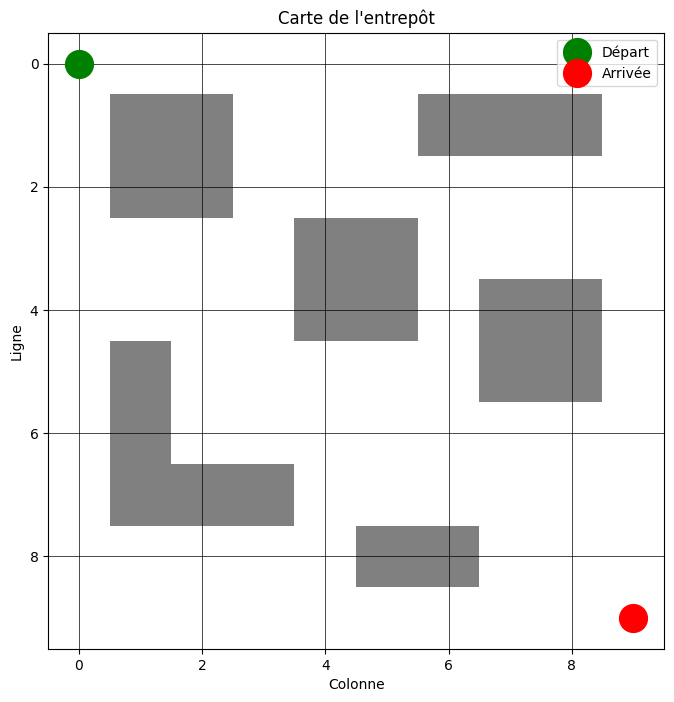

Carte créée avec succès !
Départ : (0, 0)
Arrivée : (9, 9)


In [1]:
#====1. Créer la carte de l'entrepôt====
import numpy as np # Pour créer des tableaux/grilles
import matplotlib.pyplot as plt # Pour dessiner des images
from matplotlib.colors import ListedColormap # Pour donner des couleurs

# Créer la grille de l'entrepôt
# 0 = case libre, 1 = obstacle (étagère, mur)
grille = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0, 0, 1, 1, 1, 0],
    [0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

# Point de départ (entrepôt) et arrivée (livraison)
depart = (0, 0)  # Coin en haut à gauche
arrivee = (9, 9)  # Coin en bas à droite

# Visualiser la carte
plt.figure(figsize=(8, 8)) # Créer une image de 8x8 cm
cmap = ListedColormap(['white', 'gray']) # Les couleurs : blanc = case libre, gris = obstacle
plt.imshow(grille, cmap=cmap, origin='upper') # Afficher la grille sous forme d'image
plt.plot(depart[1], depart[0], 'go', markersize=20, label='Départ') # Dessiner un gros point VERT ('go') au départ
plt.plot(arrivee[1], arrivee[0], 'ro', markersize=20, label='Arrivée') # Dessiner un gros point ROUGE ('ro') à l'arrivée
plt.grid(True, color='black', linewidth=0.5) # Ajouter une grille (quadrillage) sur l'image
plt.legend() # Afficher la légende (l'explication des symboles)
plt.title("Carte de l'entrepôt") # Ajouter un titre en haut de l'image
plt.xlabel("Colonne") # Ajouter une étiquette sur l'axe horizontal (axe X)
plt.ylabel("Ligne") # Ajouter une étiquette sur l'axe vertical (axe Y)
plt.show() # Montrer l'image à l'écran

# Affichage des informations
print("Carte créée avec succès !")
print(f"Départ : {depart}")
print(f"Arrivée : {arrivee}")

# Avec CSV
import numpy as np
# Sauvegarder la grille existante
np.savetxt("grille_entrepot.csv", grille, fmt='%d', delimiter=',')
# Charger la grille depuis CSV
grille_csv = np.loadtxt("grille_entrepot.csv", delimiter=',', dtype=int)


In [2]:
#====2. Coder l'algorithme A*====
import heapq # Gérer une file de priorité

# Fonction pour calculer la distance estimée (heuristique h)
def heuristique(a, b):
    # Distance de Manhattan (déplacements horizontaux + verticaux)
    # a = position actuelle, b = arrivée
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

# Fonction principale A*
def a_star(grille, depart, arrivee):
    lignes, colonnes = grille.shape

    # Liste pour le journal d'explication demandé
    journal = []

    # File de priorité : (f, g, position, chemin)
    file_ouverte = []
    heapq.heappush(file_ouverte, (0, 0, depart, [depart]))

    # Ensemble des positions déjà visitées
    ferme = set()

    # Stocker le meilleur coût connu
    meilleur_g = {depart: 0}

    # Compteur de nœuds explorés
    noeuds_explores = 0

    while file_ouverte:
        f, g, position_actuelle, chemin = heapq.heappop(file_ouverte)

        # Si on arrive à destination
        if position_actuelle == arrivee:
            journal.append(f"ARRIVÉE atteinte à {position_actuelle} avec coût total g={g}")
            print(f"\nChemin trouvé ! \nLongueur : {g} cases")
            print(f"Nœuds explorés : {noeuds_explores}")
            return chemin, journal, noeuds_explores

        # Si déjà visité, on passe
        if position_actuelle in ferme:
            continue

        ferme.add(position_actuelle)
        noeuds_explores += 1

        # Calcul des coûts pour ce nœud
        h = heuristique(position_actuelle, arrivee)

        # Journal détaillé
        journal.append(f"\nNœud #{noeuds_explores} : {position_actuelle}")
        journal.append(f"   Coût g (distance parcourue) = {g}")
        journal.append(f"   Coût h (estimation restante) = {h}")
        journal.append(f"   Coût f (total) = {f}")

        # Explorer les 4 voisins (haut, bas, gauche, droite)
        voisins = [
            (position_actuelle[0] - 1, position_actuelle[1]),  # Haut
            (position_actuelle[0] + 1, position_actuelle[1]),  # Bas
            (position_actuelle[0], position_actuelle[1] - 1),  # Gauche
            (position_actuelle[0], position_actuelle[1] + 1)   # Droite
        ]

        for voisin in voisins:
            ligne, col = voisin

            # Vérifier si le voisin est valide
            if 0 <= ligne < lignes and 0 <= col < colonnes:
                if grille[ligne, col] == 0:

                    nouveau_g = g + 1

                    # On accepte le voisin SEULEMENT si :
                    # on ne l'a jamais vu
                    # ou on a trouvé un chemin plus court
                    if voisin not in meilleur_g or nouveau_g < meilleur_g[voisin]:
                        meilleur_g[voisin] = nouveau_g

                        h = heuristique(voisin, arrivee)
                        f = nouveau_g + h
                        nouveau_chemin = chemin + [voisin]

                        heapq.heappush(
                            file_ouverte,
                            (f, nouveau_g, voisin, nouveau_chemin)
                        )

    print("Aucun chemin trouvé !")
    return None, journal

# LANCER A*
print("Démarrage de l'algorithme A*\n")
chemin_trouve, journal_etapes, noeuds_explores = a_star(grille, depart, arrivee)

Démarrage de l'algorithme A*


Chemin trouvé ! 
Longueur : 18 cases
Nœuds explorés : 77


In [3]:
#====3. Journal d'explication====
print("==== JOURNAL D'EXPLICATION DE A* ====")

print("\n Comment fonctionne A* :")
print("Coût g = distance déjà parcourue depuis le départ")
print("Coût h = distance estimée jusqu'à l'arrivée (heuristique)")
print("Coût f = g + h (utilisé pour choisir le prochain nœud)")
print("\n  A* choisit toujours le nœud avec le plus petit coût f\n")

print("==== Au début du parcours ====")

# Afficher les 20 premières lignes du journal
for ligne in journal_etapes[:20]:
    print(ligne)

print("\n==== A la fin du parcours ====")

# Afficher les 20 dernières lignes du journal
for ligne in journal_etapes[-20:]:
    print(ligne)

print("\n==== STATISTIQUES ==== ")
if chemin_trouve:
    print(f" Chemin trouvé avec succès !")
    print(f" Longueur du chemin : {len(chemin_trouve) - 1} déplacements")
    print(f" Nombre de cases visitées : {len(chemin_trouve)}")
    print(f"Nœuds explorés au total : {noeuds_explores}")
    print(f"\n  Chemin complet (coordonnées) :")
    for i, pos in enumerate(chemin_trouve):
        if i == 0:
            print(f"   {i}. {pos} ← DÉPART")
        elif i == len(chemin_trouve) - 1:
            print(f"   {i}. {pos} ← ARRIVÉE")
        else:
            print(f"   {i}. {pos}")

==== JOURNAL D'EXPLICATION DE A* ====

 Comment fonctionne A* :
Coût g = distance déjà parcourue depuis le départ
Coût h = distance estimée jusqu'à l'arrivée (heuristique)
Coût f = g + h (utilisé pour choisir le prochain nœud)

  A* choisit toujours le nœud avec le plus petit coût f

==== Au début du parcours ====

Nœud #1 : (0, 0)
   Coût g (distance parcourue) = 0
   Coût h (estimation restante) = 18
   Coût f (total) = 0

Nœud #2 : (0, 1)
   Coût g (distance parcourue) = 1
   Coût h (estimation restante) = 17
   Coût f (total) = 18

Nœud #3 : (1, 0)
   Coût g (distance parcourue) = 1
   Coût h (estimation restante) = 17
   Coût f (total) = 18

Nœud #4 : (0, 2)
   Coût g (distance parcourue) = 2
   Coût h (estimation restante) = 16
   Coût f (total) = 18

Nœud #5 : (2, 0)
   Coût g (distance parcourue) = 2
   Coût h (estimation restante) = 16
   Coût f (total) = 18

==== A la fin du parcours ====
   Coût g (distance parcourue) = 16
   Coût h (estimation restante) = 2
   Coût f (total

 Visualisation du chemin :



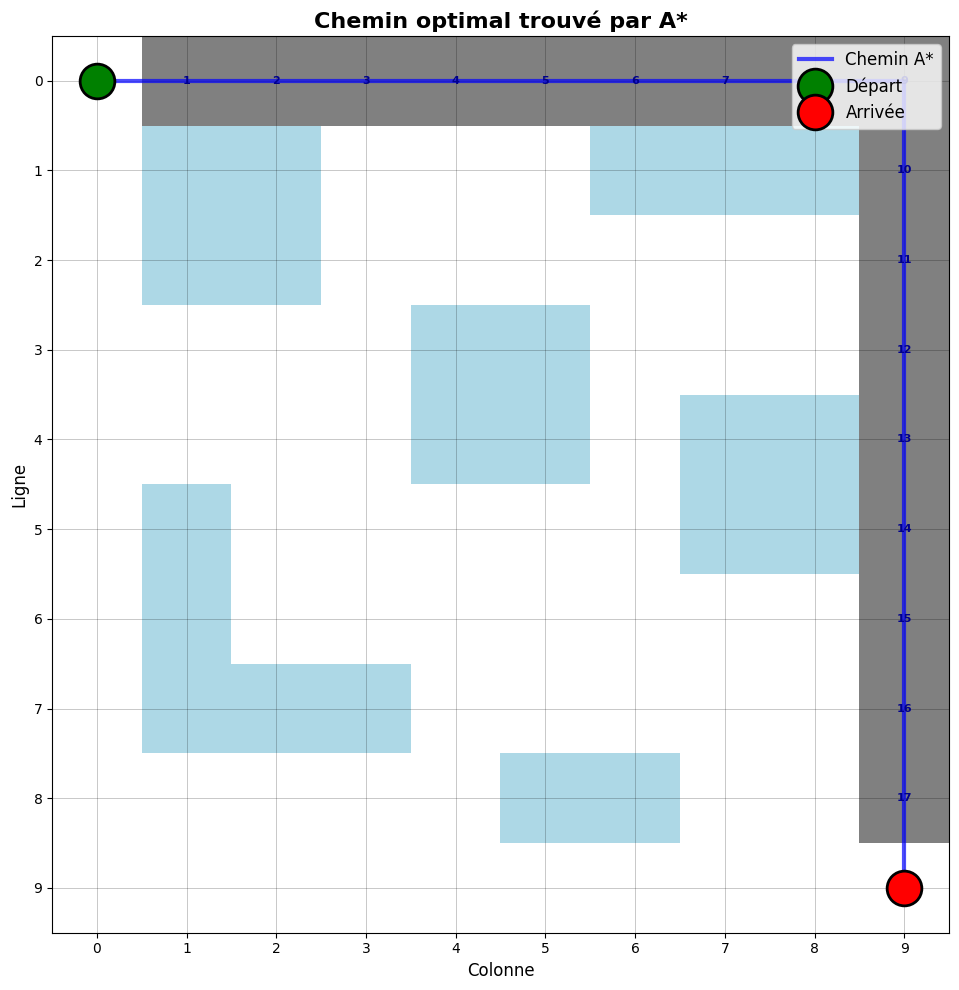


 Nombre de déplacement : 18 cases


In [4]:
#====4. Visualiser le chemin trouvé ====
def visualiser_chemin(grille, chemin, depart, arrivee):
    plt.figure(figsize=(10, 10))

    # Créer une copie de la grille pour la visualisation
    grille_visuelle = np.copy(grille).astype(float)

    # Marquer le chemin sur la grille (valeur 0.5 pour le chemin)
    if chemin:
        for position in chemin:
            if position != depart and position != arrivee:
                grille_visuelle[position] = 0.5

    # Couleurs : blanc (libre), gris (obstacle), bleu clair (chemin)
    cmap = ListedColormap(['white', 'gray', 'lightblue'])
    plt.imshow(grille_visuelle, cmap=cmap, origin='upper', vmin=0, vmax=1)

    # Tracer le chemin avec une ligne
    if chemin:
        lignes = [pos[0] for pos in chemin]
        cols = [pos[1] for pos in chemin]
        plt.plot(cols, lignes, 'b-', linewidth=3, alpha=0.7, label='Chemin A*')

    # Marquer départ et arrivée
    plt.plot(depart[1], depart[0], 'go', markersize=25, label='Départ', markeredgecolor='black', markeredgewidth=2)
    plt.plot(arrivee[1], arrivee[0], 'ro', markersize=25, label='Arrivée', markeredgecolor='black', markeredgewidth=2)

    # Ajouter les numéros des étapes sur le chemin
    if chemin and len(chemin) <= 30:  # Seulement si pas trop de points
        for i, pos in enumerate(chemin[1:-1], 1):  # Ignore départ et arrivée
            plt.text(pos[1], pos[0], str(i), ha='center', va='center',
                    fontsize=8, color='darkblue', weight='bold')

    plt.grid(True, color='black', linewidth=0.5, alpha=0.3)
    plt.legend(loc='upper right', fontsize=12)
    plt.title("Chemin optimal trouvé par A*", fontsize=16, weight='bold')
    plt.xlabel("Colonne", fontsize=12)
    plt.ylabel("Ligne", fontsize=12)

    # Ajouter les coordonnées
    plt.xticks(range(10))
    plt.yticks(range(10))

    plt.tight_layout()
    plt.show()

# AFFICHER LA VISUALISATION
if chemin_trouve:
    print(" Visualisation du chemin :\n")
    visualiser_chemin(grille, chemin_trouve, depart, arrivee)
    print(f"\n Nombre de déplacement : {len(chemin_trouve)-1 } cases")
else:
    print(" Pas de chemin à visualiser")

In [5]:
#====5. Notice d'explication====

def notice_explication():
    print("\n==== NOTICE D'EXPLICATION DE L'ALGORITHME A* ====")
    print("\n1. Contexte :")
    print("Un robot doit transporter un colis du point de départ vers le point d'arrivée en évitant les obstacles (étagères, murs) dans un entrepôt.")

    print("\n2. Fonctionnement de A* :")
    print("- g = distance déjà parcourue depuis le départ")
    print("- h = estimation de la distance restante jusqu'à l'arrivée (heuristique de Manhattan)")
    print("- f = g + h, utilisé pour choisir le nœud suivant")
    print("A* explore toujours le nœud avec le plus petit f pour trouver le chemin optimal.")

    print("\n3. Décisions clés (exemples) :")
    print("Exemple 1 : Position (1,0) → Droite bloquée par obstacle, choix : bas vers (2,0) car f minimal")
    print("Exemple 2 : Position (2,3) → Choix entre droite et bas, A* prend bas (f plus petit)")
    print("Exemple 3 : Position (5,6) → Droite bloquée, choix : bas vers (6,6), f minimal")

    print("\n4. Résultats :")
    if chemin_trouve:
        print(f"Chemin trouvé en {len(chemin_trouve)-1} déplacements")
        print(f"Nœuds explorés au total : {noeuds_explores}")
    else:
        print("Aucun chemin trouvé")

# Appeler la notice
notice_explication()



==== NOTICE D'EXPLICATION DE L'ALGORITHME A* ====

1. Contexte :
Un robot doit transporter un colis du point de départ vers le point d'arrivée en évitant les obstacles (étagères, murs) dans un entrepôt.

2. Fonctionnement de A* :
- g = distance déjà parcourue depuis le départ
- h = estimation de la distance restante jusqu'à l'arrivée (heuristique de Manhattan)
- f = g + h, utilisé pour choisir le nœud suivant
A* explore toujours le nœud avec le plus petit f pour trouver le chemin optimal.

3. Décisions clés (exemples) :
Exemple 1 : Position (1,0) → Droite bloquée par obstacle, choix : bas vers (2,0) car f minimal
Exemple 2 : Position (2,3) → Choix entre droite et bas, A* prend bas (f plus petit)
Exemple 3 : Position (5,6) → Droite bloquée, choix : bas vers (6,6), f minimal

4. Résultats :
Chemin trouvé en 18 déplacements
Nœuds explorés au total : 77
